# Phase 0 — andito subset: CLIP encoding + photo filter

Mirrors `phase0.ipynb` for the **andito/google-landmarks Egyptian subset** that was streamed via Colab into a flat directory at `egyptian_landmarks_data/images/`.

Outputs:
- `embeddings/andito_image_features_clean.pt`
- `embeddings/andito_image_paths_clean.pkl`

In [1]:
# ── Environment guards (must run before native imports) ──────────────────────
import os
os.environ["OMP_NUM_THREADS"]             = "1"
os.environ["MKL_NUM_THREADS"]             = "1"
os.environ["VECLIB_MAXIMUM_THREADS"]      = "1"
os.environ["NUMEXPR_NUM_THREADS"]         = "1"
os.environ["KMP_DUPLICATE_LIB_OK"]        = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"]      = "false"
os.environ["KMP_INIT_AT_FORK"]            = "FALSE"

import glob, pickle
import numpy as np
import torch
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

import clip
from PIL import Image
from tqdm.auto import tqdm

device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()
print(f"CLIP loaded on {device}")

/Users/khal1dx/Desktop/khal1dx/GUC/Bach/Project/V0/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLIP loaded on mps


## 1. Encode all andito images

In [2]:
# Flat directory of JPGs — filenames are `<rownum>_<sanitized_name>.jpg`
image_paths = sorted(glob.glob("egyptian_landmarks_data/images/*.jpg"))
print(f"Found {len(image_paths)} images.")
assert image_paths, "No images found at egyptian_landmarks_data/images/"

# Encode in batches for speed (CLIP ViT-B/32 handles ~64 at once on MPS)
BATCH = 32
feats_chunks = []
kept_paths   = []

for start in tqdm(range(0, len(image_paths), BATCH), desc="Encoding"):
    batch_paths = image_paths[start:start + BATCH]
    batch_imgs  = []
    batch_kept  = []
    for p in batch_paths:
        try:
            img = preprocess(Image.open(p).convert("RGB"))
            batch_imgs.append(img)
            batch_kept.append(p)
        except Exception as exc:
            print(f"  skip {p}: {exc}")
    if not batch_imgs:
        continue
    batch_tensor = torch.stack(batch_imgs).to(device)
    with torch.no_grad():
        f = model.encode_image(batch_tensor)
        f /= f.norm(dim=-1, keepdim=True)
    feats_chunks.append(f.cpu())
    kept_paths.extend(batch_kept)

image_features = torch.cat(feats_chunks)
print(f"Image feature shape: {image_features.shape}  ({len(kept_paths)} paths)")

Found 4224 images.


Encoding: 100%|██████████| 132/132 [01:14<00:00,  1.77it/s]

Image feature shape: torch.Size([4224, 512])  (4224 paths)


In [3]:
# Save raw (pre-filter) embeddings
os.makedirs("embeddings", exist_ok=True)
torch.save(image_features, "embeddings/andito_image_features.pt")
with open("embeddings/andito_image_paths.pkl", "wb") as f:
    pickle.dump(kept_paths, f)
print("Saved raw embeddings -> embeddings/andito_image_features.pt")
print("Saved raw paths     -> embeddings/andito_image_paths.pkl")

Saved raw embeddings -> embeddings/andito_image_features.pt
Saved raw paths     -> embeddings/andito_image_paths.pkl


## 2. Photo filter (drop diagrams / 3D renders)

Same three text anchors as `phase0.ipynb`. Keeps images where the
"real photograph" anchor scores higher than both negatives.

In [4]:
image_features = torch.load("embeddings/andito_image_features.pt", weights_only=True).to(device)
with open("embeddings/andito_image_paths.pkl", "rb") as f:
    image_paths = pickle.load(f)

filter_texts = clip.tokenize([
    "a real photograph of a landmark or building",
    "an architectural diagram, floor plan, or technical drawing",
    "a 3D render or computer generated illustration",
]).to(device)

with torch.no_grad():
    filter_feats = model.encode_text(filter_texts)
    filter_feats /= filter_feats.norm(dim=-1, keepdim=True)
    scores = (image_features @ filter_feats.T)

keep_mask    = scores[:, 0] > scores[:, 1:].max(dim=1).values
keep_indices = keep_mask.nonzero(as_tuple=True)[0].tolist()
filtered_features = image_features[keep_mask].cpu()
filtered_paths    = [image_paths[i] for i in keep_indices]

removed = len(image_paths) - len(filtered_paths)
print(f"Removed {removed} non-photographic images ({removed/len(image_paths)*100:.1f}%)")
print(f"Clean index: {len(filtered_paths)} images")

torch.save(filtered_features, "embeddings/andito_image_features_clean.pt")
with open("embeddings/andito_image_paths_clean.pkl", "wb") as f:
    pickle.dump(filtered_paths, f)
print("Saved -> embeddings/andito_image_features_clean.pt")
print("Saved -> embeddings/andito_image_paths_clean.pkl")

Removed 473 non-photographic images (11.2%)
Clean index: 3751 images
Saved -> embeddings/andito_image_features_clean.pt
Saved -> embeddings/andito_image_paths_clean.pkl


## 3. Sanity check — encode a sketch and show top-5 from the clean index

Top 5 for sketch 'pyramid-mid.jpg' (clean andito index):
  [1] 0.7900  923609_This_appears_to_be_related_to_Pyramid_of_Djedefra
  [2] 0.7583  536400_Funerary_Temple_of_Khafre
  [3] 0.7485  9362_Funerary_Temple_of_Khafre
  [4] 0.7422  720953_Funerary_Temple_of_Khafre
  [5] 0.7412  1106066_Funerary_Temple_of_Khafre


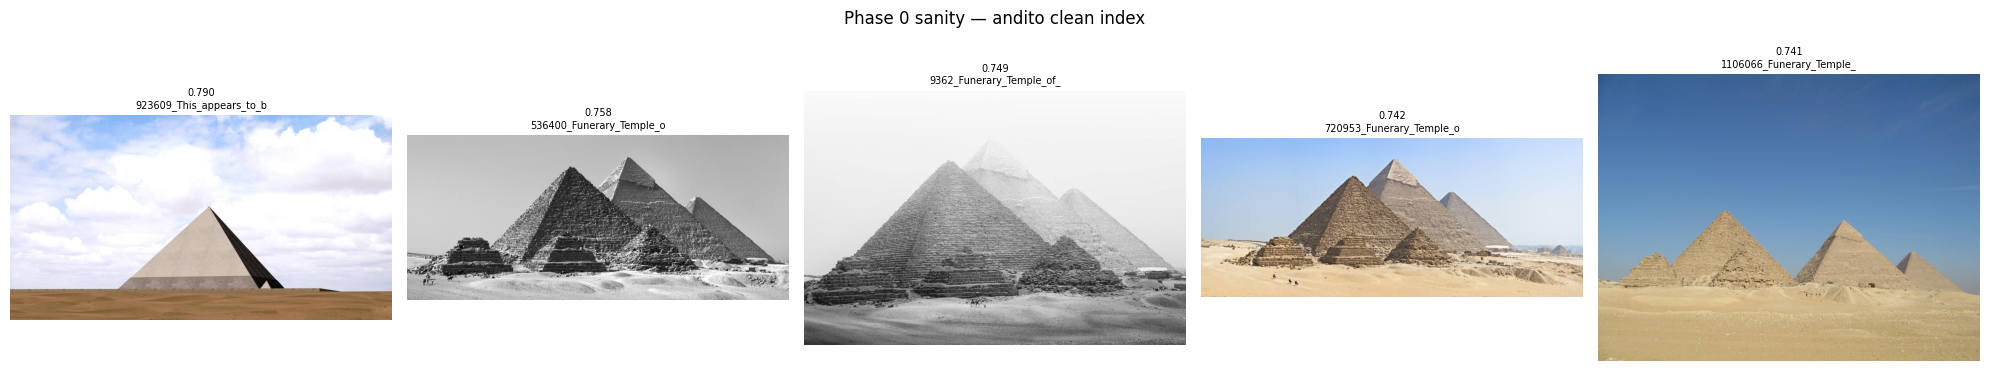

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sketch_path = "pyramid-mid.jpg"
sketch = preprocess(Image.open(sketch_path).convert("RGB")).unsqueeze(0).to(device)
with torch.no_grad():
    sketch_feat = model.encode_image(sketch)
    sketch_feat /= sketch_feat.norm(dim=-1, keepdim=True)

filtered_features_dev = filtered_features.to(device)
sims = (sketch_feat @ filtered_features_dev.T).cpu().numpy()
top  = sims.argsort()[0][-5:][::-1]

print(f"Top 5 for sketch '{sketch_path}' (clean andito index):")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, idx in enumerate(top):
    p = filtered_paths[idx]
    name = os.path.basename(p).rsplit(".", 1)[0]
    print(f"  [{i+1}] {sims[0][idx]:.4f}  {name}")
    try:
        axes[i].imshow(mpimg.imread(p))
        axes[i].set_title(f"{sims[0][idx]:.3f}\n{name[:24]}", fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("Phase 0 sanity — andito clean index", fontsize=12)
plt.tight_layout()
plt.show()